In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Train shape: (60000, 28, 28)


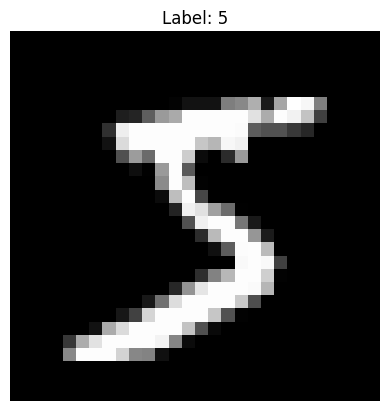

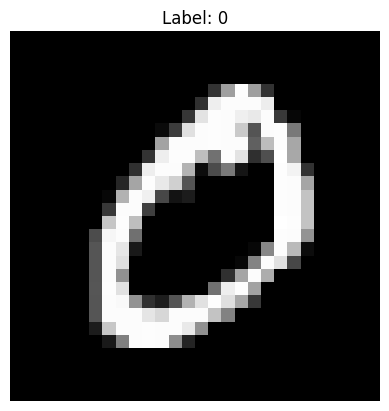

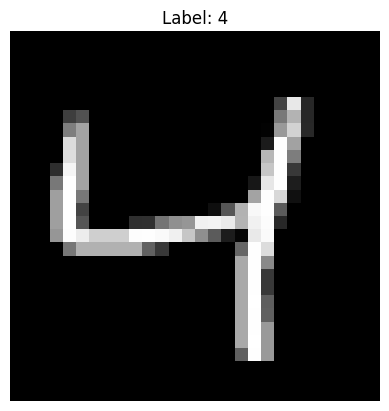

In [3]:
print("Train shape:", X_train.shape)   # (60000, 28, 28)

for i in range(3):
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()

In [4]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension → (28,28,1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.8507 - loss: 0.5271
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 24ms/step - accuracy: 0.9561 - loss: 0.1468
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9699 - loss: 0.0995
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 24ms/step - accuracy: 0.9757 - loss: 0.0791
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9794 - loss: 0.0680


In [8]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9831 - loss: 0.0538
Test Accuracy: 0.9830999970436096


In [9]:
sample = X_test[0].reshape(1, 28, 28, 1)
pred = model.predict(sample)

print("Predicted:", np.argmax(pred))
print("Actual:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted: 7
Actual: 7


In [10]:
batch = X_test[:5]
preds = model.predict(batch)

print("Predicted:", np.argmax(preds, axis=1))
print("Actual:", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted: [7 2 1 0 4]
Actual: [7 2 1 0 4]
